## Lab: Automated Red-Teaming with ART

### Step 1: Install and Initialize

ART is a comprehensive library that supports PyTorch, TensorFlow, and Scikit-learn. We need to install it and set up our environment.

In [1]:
# Install ART
!pip install adversarial-robustness-toolbox

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from torchvision import datasets, transforms
from art.estimators.classification import PyTorchClassifier
from art.attacks.evasion import FastGradientMethod, DeepFool

# Setup device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 35.5 MB/s eta 0:00:00


---

### Step 2: Prepare the Model and Data

We will use a simple NN.
Note that ART works with **NumPy arrays** for data, so we will convert our MNIST tensors to NumPy after loading.

In [2]:
# 1. Define Model
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, 1)
        self.fc = nn.Linear(5408, 10)
    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.max_pool2d(x, 2)
        return F.log_softmax(self.fc(torch.flatten(x, 1)), dim=1)

model = Net().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

# 2. Load Data (Convert to NumPy for ART)
train_loader = torch.utils.data.DataLoader(datasets.MNIST('./data', train=True, download=True, transform=transforms.ToTensor()), batch_size=128, shuffle=True)
test_loader = torch.utils.data.DataLoader(datasets.MNIST('./data', train=False, transform=transforms.ToTensor()), batch_size=1000)

# Quick training loop
model.train()
for i, (data, target) in enumerate(train_loader):
    data, target = data.to(device), target.to(device)
    optimizer.zero_grad(); F.nll_loss(model(data), target).backward(); optimizer.step()
    if i > 100: break # Quick train
model.eval()

# Extract a subset of test data as NumPy arrays for ART
x_test, y_test = next(iter(test_loader))
x_test = x_test.numpy()
y_test = y_test.numpy()

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.06MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 134kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.27MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.84MB/s]


---

### Step 3: Wrap the Model in ART

ART uses a "Wrapper" called a `Classifier`. This allows ART to talk to PyTorch without you having to manually handle gradients, device transfers, or loss functions during the attack.

In [3]:
# Define the loss and optimizer for the wrapper
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

# Wrap the model
classifier = PyTorchClassifier(
    model=model,
    loss=criterion,
    optimizer=optimizer,
    input_shape=(1, 28, 28),
    nb_classes=10,
    device_type='gpu' if torch.cuda.is_available() else 'cpu'
)

---

### Step 4: Run the Automated Attack (FGSM)

Now, instead of writing the math for FGSM, we simply call ART's `FastGradientMethod`. We will generate adversarial examples for the entire test batch in one line.

In [4]:
# Create the attack object
attack_fgsm = FastGradientMethod(estimator=classifier, eps=0.2)

# Generate adversarial examples
x_test_adv = attack_fgsm.generate(x=x_test)

# Evaluate
predictions = np.argmax(classifier.predict(x_test), axis=1)
accuracy_clean = np.sum(predictions == y_test) / len(y_test)

predictions_adv = np.argmax(classifier.predict(x_test_adv), axis=1)
accuracy_adv = np.sum(predictions_adv == y_test) / len(y_test)

print(f"Clean Accuracy: {accuracy_clean:.1%}")
print(f"Adversarial Accuracy (FGSM): {accuracy_adv:.1%}")

Clean Accuracy: 94.8%
Adversarial Accuracy (FGSM): 8.6%


---

### Step 5: Red-teaming with DeepFool

FGSM is a "low-effort" attack. To really test robustness, we use **DeepFool**, an iterative attack that tries to find the absolute minimum amount of noise needed to flip a label. This is much harder to defend against.

In [5]:
# Create DeepFool attack
attack_df = DeepFool(classifier=classifier)

# Generate examples (this may take a moment as it is iterative)
x_test_deepfool = attack_df.generate(x=x_test[:100]) # Just 100 samples for speed

# Evaluate
df_preds = np.argmax(classifier.predict(x_test_deepfool), axis=1)
df_acc = np.sum(df_preds == y_test[:100]) / 100

print(f"DeepFool Accuracy: {df_acc:.1%}")

DeepFool:   0%|          | 0/100 [00:00<?, ?it/s]

DeepFool Accuracy: 3.0%


---

### Step 6: Visualizing the "Robustness Gap"

Finally, we compare the two attacks. Students should notice that while FGSM adds a visible "haze," DeepFool often flips the label with noise that is almost invisible to the human eye.

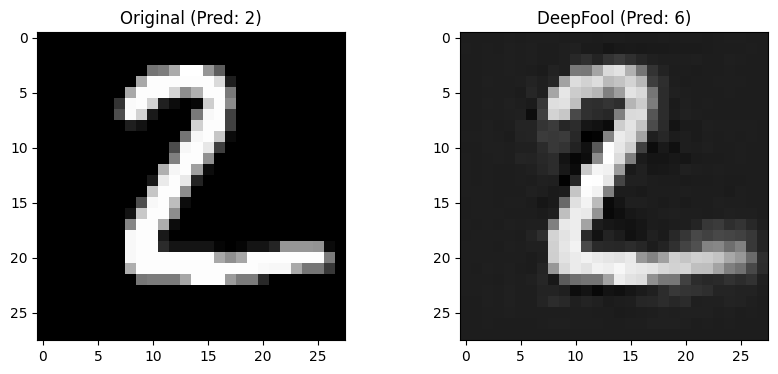

In [7]:
import matplotlib.pyplot as plt

# Compare original vs DeepFool
idx = 1  # change rge value of idx to select different images
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(x_test[idx].reshape(28, 28), cmap='gray')
plt.title(f"Original (Pred: {predictions[idx]})")

plt.subplot(1, 2, 2)
plt.imshow(x_test_deepfool[idx].reshape(28, 28), cmap='gray')
plt.title(f"DeepFool (Pred: {df_preds[idx]})")

plt.show()

**DeepFool** is significantly more efficient than FGSM. While FGSM uses a fixed "budget" ($\epsilon$) that often makes the image look messy, DeepFool computes the **shortest distance** to the decision boundary.
